In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from scipy.stats import wasserstein_distance

selection = "ATLAS"
sample_path = f"Models_Extrapolation_{selection}_ver2/samples"
dataset_path = f"Final_Dataset_{selection}"

N_ENSEMBLE = 10

context_vars = ['met_recalc_pt', 'ht']
features_vars = ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj']

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
# Load Reweight Events
mc_cr_reweight_events = pd.read_parquet(f"{sample_path}/MC_CR_reweighted.parquet")

# Load Generate Events

mc_cr_generate_dfs = []
for i in range(N_ENSEMBLE):
    df = pd.read_parquet(f"{sample_path}/MC_CR_Generate_ens{i}.parquet")
    mc_cr_generate_dfs.append(df)


data_cr_events = pd.read_parquet(f"{dataset_path}/CR_Dataset_Splits/DATA_events_test.parquet")

Data events shape: (21983, 10)
Reweighted events shape: (84161, 22)
Generated events shapes: [(84161, 9), (84161, 9), (84161, 9), (84161, 9), (84161, 9), (84161, 9), (84161, 9), (84161, 9), (84161, 9), (84161, 9)]
 == Check W1 ==
Data W1: 0.0


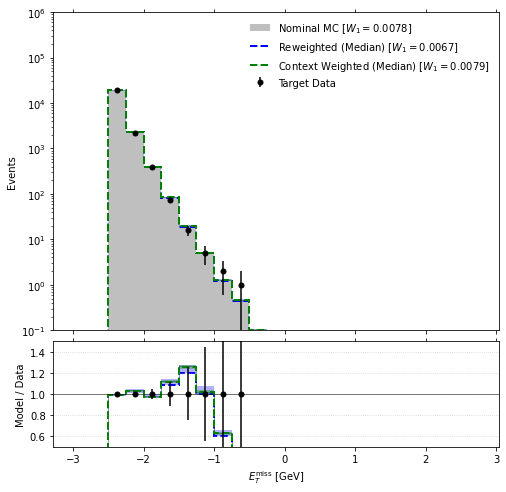

 == Check W1 ==
Data W1: 0.0


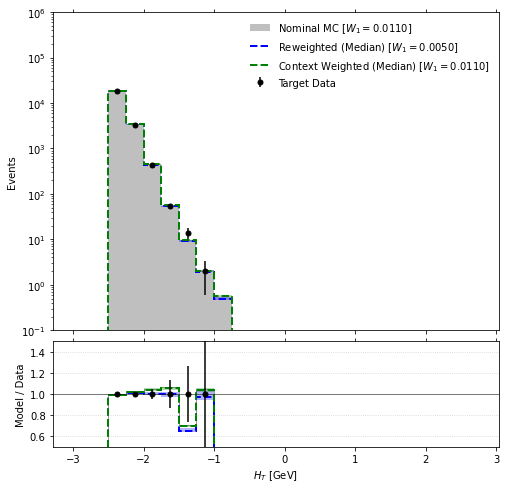

 == Check W1 ==
Data W1: 0.0


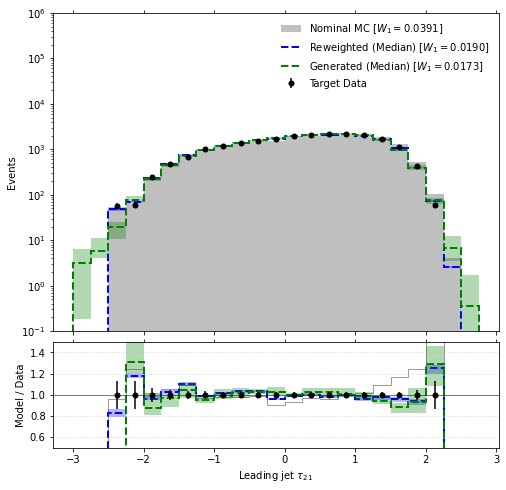

 == Check W1 ==
Data W1: 0.0


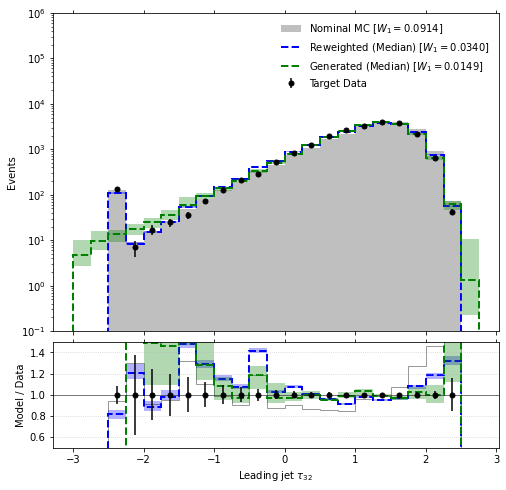

 == Check W1 ==
Data W1: 0.0


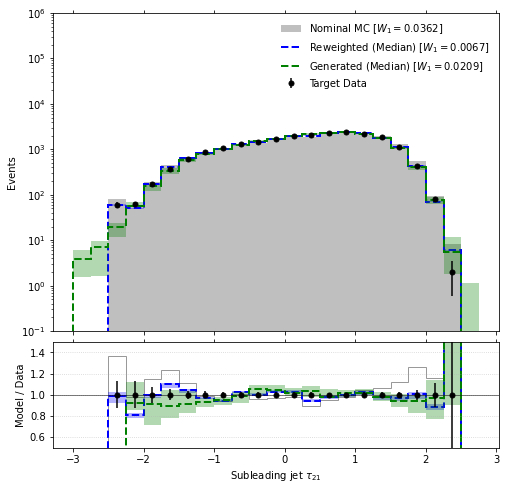

 == Check W1 ==
Data W1: 0.0


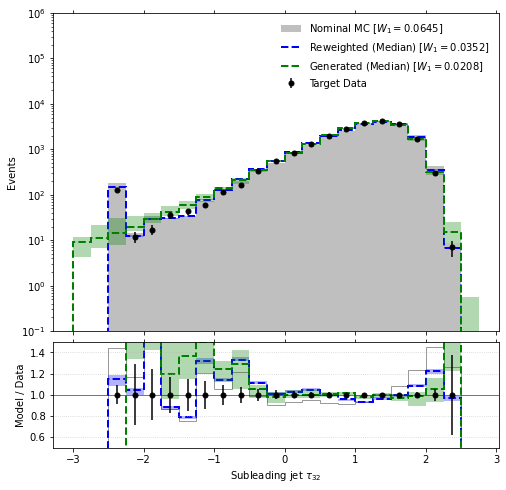

 == Check W1 ==
Data W1: 0.0


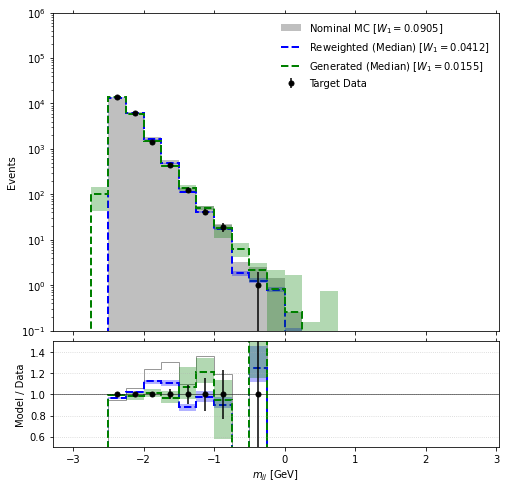

In [4]:
def plot_context_events(data_events, reweight_events, generate_events):
    print(f"Data events shape: {data_events.shape}")
    print(f"Reweighted events shape: {reweight_events.shape}")
    print(f"Generated events shapes: {[gen_events.shape for gen_events in generate_events]}")

    bins = np.arange(-3.0, 3.0, 0.25)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    pretty_labels = {
        'ht': r'$H_{T}$ [GeV]',
        'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]',
        'met': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'mjj': r'$m_{jj}$ [GeV]',
        'ljet1_tau21': r'Leading jet $\tau_{21}$',
        'ljet1_tau32': r'Leading jet $\tau_{32}$',
        'ljet2_tau21': r'Subleading jet $\tau_{21}$',
        'ljet2_tau32': r'Subleading jet $\tau_{32}$'
    }

    for var in context_vars + features_vars:
        # Create a figure with two vertically stacked panels
        fig, (ax1, ax2) = plt.subplots(
            2, 1, 
            figsize=(8, 8), 
            gridspec_kw={'height_ratios': [3, 1]}, 
            sharex=True
        )
        
        # Remove horizontal space between axes
        fig.subplots_adjust(hspace=0.05)

        # ==========================================
        # TARGET DATA (Calculated once for both panels)
        # ==========================================
        data_arr = data_events[var].to_numpy()
        counts_data, _ = np.histogram(data_arr, bins=bins)
        data_errors = np.sqrt(counts_data)
        std_data = np.std(data_arr)
        w1_data = wasserstein_distance(bin_centers, bin_centers, u_weights=counts_data, v_weights=counts_data)/std_data

        print(" == Check W1 ==")
        print("Data W1:", w1_data)
        
        # Top panel: Data
        ax1.errorbar(bin_centers, counts_data, yerr=data_errors, fmt='ko', label='Target Data', zorder=10, capsize=0, markersize=5)

        # Bottom panel: Data reference at 1.0
        # Safe division to get fractional errors for the ratio plot
        valid = counts_data > 0
        data_ratio_err = np.zeros_like(counts_data, dtype=float)
        data_ratio_err[valid] = data_errors[valid] / counts_data[valid]
        
        ax2.errorbar(bin_centers[valid], np.ones_like(counts_data[valid]), yerr=data_ratio_err[valid], fmt='ko', zorder=10, capsize=0, markersize=5)
        ax2.axhline(1.0, color='black', linestyle='-', linewidth=1, alpha=0.5)

        # ==========================================
        # NOMINAL MC
        # ==========================================
        mc_reweight_arr = reweight_events[var].to_numpy()
        nominal_weights = reweight_events['final_weight'].to_numpy()
        
        counts_nom, _ = np.histogram(mc_reweight_arr, bins=bins, weights=nominal_weights)
        w1_nom = wasserstein_distance(bin_centers, bin_centers, u_weights=counts_data, v_weights=counts_nom)/std_data
        ax1.stairs(counts_nom, bins, fill=True, color="grey", alpha=0.5, label=f'Nominal MC [$W_1 = {w1_nom:.4f}$]')
        
        # Nominal ratio
        ratio_nom = np.divide(counts_nom, counts_data, out=np.full_like(counts_nom, np.nan, dtype=float), where=valid)
        ax2.stairs(ratio_nom, bins, color="grey", alpha=0.8)

        # ==========================================
        # REWEIGHT EVENTS
        # ==========================================
        rw_binned = [] 
        for i in range(N_ENSEMBLE):
            rw_weight = reweight_events[f'reweight_weights_ens{i}'].to_numpy()
            counts, _ = np.histogram(mc_reweight_arr, bins=bins, weights=nominal_weights * rw_weight)
            rw_binned.append(counts)
            
        rw_median = np.median(rw_binned, axis=0)
        rw_lower = np.percentile(rw_binned, 2.5, axis=0)
        rw_upper = np.percentile(rw_binned, 97.5, axis=0)
        
        rw_lower_clip = np.clip(rw_lower, 1e-3, None)
        rw_median_clip = np.clip(rw_median, 1e-3, None)

        w1_rw = wasserstein_distance(bin_centers, bin_centers, u_weights=counts_data, v_weights=rw_median)/std_data
        # Top panel
        ax1.stairs(rw_median_clip, bins, color="blue", linewidth=2, linestyle='--', label=f'Reweighted (Median) [$W_1 = {w1_rw:.4f}$]')
        ax1.stairs(rw_upper, bins, baseline=rw_lower_clip, fill=True, color='blue', alpha=0.3)

        # Bottom panel
        rw_ratio_med = np.divide(rw_median, counts_data, out=np.full_like(rw_median, np.nan, dtype=float), where=valid)
        rw_ratio_low = np.divide(rw_lower, counts_data, out=np.full_like(rw_lower, np.nan, dtype=float), where=valid)
        rw_ratio_up = np.divide(rw_upper, counts_data, out=np.full_like(rw_upper, np.nan, dtype=float), where=valid)
        
        ax2.stairs(rw_ratio_med, bins, color="blue", linewidth=2, linestyle='--')
        ax2.stairs(rw_ratio_up, bins, baseline=rw_ratio_low, fill=True, color='blue', alpha=0.3)

        # ==========================================
        # CONTEXT WEIGHTS
        # ==========================================
        cw_binned = [] 
        for i in range(N_ENSEMBLE):
            cw_weight = generate_events[i]['total_weight'].to_numpy() 
            cw_arr = generate_events[i][var].to_numpy() 
            counts, _ = np.histogram(cw_arr, bins=bins, weights=cw_weight)
            cw_binned.append(counts)
            
        cw_median = np.median(cw_binned, axis=0)
        cw_lower = np.percentile(cw_binned, 2.5, axis=0)
        cw_upper = np.percentile(cw_binned, 97.5, axis=0)

        cw_lower_clip = np.clip(cw_lower, 1e-3, None)
        cw_median_clip = np.clip(cw_median, 1e-3, None)

        w1_cw = wasserstein_distance(bin_centers, bin_centers, u_weights=counts_data, v_weights=cw_median)/std_data
        # Top panel
        if var in context_vars:
            label_gen = 'Context Weighted (Median)'
        else:
            label_gen = 'Generated (Median)'
        ax1.stairs(cw_median_clip, bins, color="green", linewidth=2, linestyle='--', label=f'{label_gen} [$W_1 = {w1_cw:.4f}$]')
        ax1.stairs(cw_upper, bins, baseline=cw_lower_clip, fill=True, color='green', alpha=0.3)

        # Bottom panel
        cw_ratio_med = np.divide(cw_median, counts_data, out=np.full_like(cw_median, np.nan, dtype=float), where=valid)
        cw_ratio_low = np.divide(cw_lower, counts_data, out=np.full_like(cw_lower, np.nan, dtype=float), where=valid)
        cw_ratio_up = np.divide(cw_upper, counts_data, out=np.full_like(cw_upper, np.nan, dtype=float), where=valid)

        ax2.stairs(cw_ratio_med, bins, color="green", linewidth=2, linestyle='--')
        ax2.stairs(cw_ratio_up, bins, baseline=cw_ratio_low, fill=True, color='green', alpha=0.3)

        # ==========================================
        # PLOT FORMATTING
        # ==========================================
        # Top Panel
        ax1.set_yscale('log')
        ax1.set_ylim(0.1, 1e6)
        ax1.set_ylabel('Events')
        ax1.legend(frameon=False)
        ax1.tick_params(axis='x', which='both', bottom=True, top=True, labelbottom=False)

        # Bottom Panel (Ratio)
        ax2.set_ylabel('Model / Data')
        # Adjust these limits based on how wild your ratios get. 0.5 to 1.5 is standard.
        ax2.set_ylim(0.5, 1.5) 
        ax2.set_xlabel(pretty_labels.get(var, var))
        ax2.tick_params(axis='x', which='both', bottom=True, top=True)
        ax2.grid(True, axis='y', linestyle=':', alpha=0.6)

        plt.show()
plot_context_events(data_cr_events, mc_cr_reweight_events, mc_cr_generate_dfs)

In [5]:
# Run Classifier Ensemble
import os
import sys
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

helpers_path = os.path.join('/home/aegis/Titan1/NRAD/data/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier


def run_eval(set_1, set_2, code, save_dir, classifier_params, device, w_1=None, w_2=None, classifier_runs=20):
    
    if w_1 is None or w_1.size == 0:
        w_1 = np.ones(set_1.shape[0])
    if w_2 is None or w_2.size == 0:
        w_2 = np.ones(set_2.shape[0])

    n_features = set_1.shape[1]
    
    # ---------- Logging ----------
    print(f"\nWorking on {code}...")
    print(f"      Total Events - Set 1: {set_1.shape[0]}, Set 2: {set_2.shape[0]}")
    
    aucs_list = []

    for i in range(int(classifier_runs)):
        print(f"\nClassifier run {i+1} of {classifier_runs}.")
        local_id = f"{code}_run{i}"
        
        # 2 & 4. SPLIT INSIDE THE LOOP (Flat 20% Test Size)
        # random_state=i ensures a unique train/test combination for each of the 20 runs.
        trainset_1, testset_1, wtrain_1, wtest_1 = train_test_split(
            set_1, w_1, test_size=0.2, random_state=i
        )
        trainset_2, testset_2, wtrain_2, wtest_2 = train_test_split(
            set_2, w_2, test_size=0.2, random_state=i
        )

        # 1. APPLY WEIGHTS AS IS
        # No scaling/normalization applied here to preserve Anomaly Detection physics.
        input_x_train = np.concatenate([trainset_1, trainset_2], axis=0)
        input_y_train = np.concatenate([
            np.zeros(trainset_1.shape[0]),
            np.ones(trainset_2.shape[0])
        ]).reshape(-1, 1)
        
        # Concatenate raw training weights directly
        input_w_train = np.concatenate([wtrain_1, wtrain_2], axis=0).reshape(-1, 1)

        input_x_test = np.concatenate([testset_1, testset_2], axis=0)
        input_y_test = np.concatenate([
            np.zeros(testset_1.shape[0]),
            np.ones(testset_2.shape[0])
        ]).reshape(-1, 1)
        
        # Concatenate raw testing weights directly
        combined_test_weights = np.concatenate([wtest_1, wtest_2])

        if i == 0:
            print(f"      Train shapes: X:{input_x_train.shape}, y:{input_y_train.shape}, w:{input_w_train.shape}")
            print(f"      Test shapes: X:{input_x_test.shape}, y:{input_y_test.shape}")
                
        # 3. NO SCALING APPLIED (scale_data=False)
        NN = Classifier(n_inputs=n_features, layers=classifier_params["layers"], 
                        learning_rate=classifier_params["learning_rate"], device=device, scale_data=False)
        
        if i == 0: print("Using device:", NN.device)
        
        NN.train(input_x_train, input_y_train, weights=input_w_train, save_model=True, 
                 model_name=f"model_{local_id}", n_epochs=classifier_params["n_epochs"], seed=i, outdir=save_dir)

        # 4. EVALUATION
        scores = NN.evaluation(input_x_test)
        auc = roc_auc_score(input_y_test, scores, sample_weight=combined_test_weights)
        
        if auc < 0.5:
            auc = 1.0 - auc  # symmetry adjustment
            
        aucs_list.append(auc)
        print(f"   --> AUC: {auc:.4f}")
    
    # ---------- Save results ----------
    os.makedirs(f"{save_dir}/auc_scores", exist_ok=True)
    np.savez(f"{save_dir}/auc_scores/auc_{code}.npz", auc_scores=np.array(aucs_list))

    print("\n--- Summary for", code, "---")
    print(f"Median AUC:       {np.median(aucs_list):.4f}")
    print(f"16th percentile:  {np.percentile(aucs_list, 16):.4f}")
    print(f"84th percentile:  {np.percentile(aucs_list, 84):.4f}")
    print("Done.\n")

In [6]:
device = torch.device("cpu")
print("Device:", device)
config_path = "/home/aegis/Titan1/NRAD/data/configs"
eval_dir = f"Eval_CWoLa_CR_{selection}_ver2"
os.makedirs(eval_dir, exist_ok=True)
with open(f"{config_path}/bc_discrim.yml", 'r') as stream:
    params = yaml.safe_load(stream)

Device: cpu


In [7]:
print("CWoLa CR: Data vs Nominal")

features_data = data_cr_events[features_vars].values
w_data = np.ones(len(features_data))
features_nom = mc_cr_reweight_events[features_vars].values
w_nom = mc_cr_reweight_events["final_weight"].values
run_eval(features_data, features_nom, code=f"Data_vs_Nom_{selection}", save_dir=eval_dir, classifier_params=params, device=device, w_1=w_data, w_2=w_nom)

CWoLa CR: Data vs Nominal

Working on Data_vs_Nom_ATLAS...
      Total Events - Set 1: 21983, Set 2: 84161

Classifier run 1 of 20.
      Train shapes: X:(84914, 5), y:(84914, 1), w:(84914, 1)
      Test shapes: X:(21230, 5), y:(21230, 1)
Using device: cpu


 32%|===       | 16/50 [01:43<03:40,  6.49s/it]


   --> AUC: 0.5577

Classifier run 2 of 20.


 20%|==        | 10/50 [01:08<04:35,  6.89s/it]


   --> AUC: 0.5638

Classifier run 3 of 20.


...

   --> AUC: 0.5641

Classifier run 19 of 20.


 28%|==>       | 14/50 [01:12<03:07,  5.21s/it]


   --> AUC: 0.5646

Classifier run 20 of 20.


 20%|==        | 10/50 [01:01<04:05,  6.14s/it]

   --> AUC: 0.5570

--- Summary for Data_vs_Nom_ATLAS ---
Median AUC:       0.5570
16th percentile:  0.5532
84th percentile:  0.5618
Done.



In [8]:
print(f"CWoLa CR: Data vs Reweight (Median of {N_ENSEMBLE} models)")

features_rw = mc_cr_reweight_events[features_vars].values
nominal_w = mc_cr_reweight_events["final_weight"].values

rw_ensemble_weights = [mc_cr_reweight_events[f'reweight_weights_ens{i}'].values for i in range(N_ENSEMBLE)]
rw_median = np.median(rw_ensemble_weights, axis=0)
w_rw_median = nominal_w * rw_median

run_eval(
    features_data, features_rw, 
    code=f"Data_vs_Reweight_Median_{selection}", 
    save_dir=eval_dir, classifier_params=params, device=device, 
    w_1=w_data, w_2=w_rw_median
)

CWoLa CR: Data vs Reweight (Median of 10 models)

Working on Data_vs_Reweight_Median_ATLAS...
      Total Events - Set 1: 21983, Set 2: 84161

Classifier run 1 of 20.
      Train shapes: X:(84914, 5), y:(84914, 1), w:(84914, 1)
      Test shapes: X:(21230, 5), y:(21230, 1)
Using device: cpu


 12%|=         | 6/50 [00:35<04:23,  5.98s/it]


   --> AUC: 0.5190

Classifier run 2 of 20.


 32%|===       | 16/50 [01:33<03:18,  5.85s/it]


   --> AUC: 0.5223

Classifier run 3 of 20.


...

   --> AUC: 0.5158

Classifier run 19 of 20.


 14%|=         | 7/50 [00:42<04:20,  6.07s/it]


   --> AUC: 0.5171

Classifier run 20 of 20.


 24%|==        | 12/50 [01:08<03:36,  5.69s/it]

   --> AUC: 0.5120

--- Summary for Data_vs_Reweight_Median_ATLAS ---
Median AUC:       0.5174
16th percentile:  0.5134
84th percentile:  0.5191
Done.



In [9]:
print(f"CWoLa CR: Data vs Generate (Combined {N_ENSEMBLE} models)")

features_gen_combined = np.vstack([df[features_vars].values for df in mc_cr_generate_dfs])

w_gen_combined = np.concatenate([df['total_weight'].values for df in mc_cr_generate_dfs]) / N_ENSEMBLE

run_eval(
    features_data, features_gen_combined, 
    code=f"Data_vs_Generate_Combined_{selection}", 
    save_dir=eval_dir, classifier_params=params, device=device, 
    w_1=w_data, w_2=w_gen_combined
)

CWoLa CR: Data vs Generate (Combined 10 models)

Working on Data_vs_Generate_Combined_ATLAS...
      Total Events - Set 1: 21983, Set 2: 841610

Classifier run 1 of 20.
      Train shapes: X:(690874, 5), y:(690874, 1), w:(690874, 1)
      Test shapes: X:(172719, 5), y:(172719, 1)
Using device: cpu


 18%|=>        | 9/50 [02:02<09:19, 13.65s/it]


   --> AUC: 0.5109

Classifier run 2 of 20.


 12%|=         | 6/50 [01:26<10:31, 14.36s/it]


   --> AUC: 0.5137

Classifier run 3 of 20.


...

   --> AUC: 0.5132

Classifier run 19 of 20.


 20%|==        | 10/50 [02:18<09:15, 13.90s/it]


   --> AUC: 0.5081

Classifier run 20 of 20.


 52%|=====     | 26/50 [05:51<05:24, 13.54s/it]

   --> AUC: 0.5182

--- Summary for Data_vs_Generate_Combined_ATLAS ---
Median AUC:       0.5115
16th percentile:  0.5083
84th percentile:  0.5190
Done.

